# Pruebas de Significancia Estadística: G-Eval vs Sistema de Votación

**Proyecto de tesis** — Tercer notebook del bloque de análisis. Cierra
la pregunta abierta tras HU-11 (correlación con CIs): ¿la diferencia
observada entre G-Eval y el sistema de votación es estadísticamente
significativa o atribuible a ruido de muestreo?

El análisis se descompone en tres planos, cada uno con el test
apropiado para el diseño de los datos (muestras dependientes, escala
ordinal 1–5, n = 900):

- **Exactitud contra el humano** — Wilcoxon signed-rank (principal,
  no paramétrico) sobre la diferencia de errores absolutos
  `|err_geval| − |err_voting|`; t pareado complementario sobre la
  misma cantidad. Esta es la pregunta de "¿cuál se acerca más al
  juicio humano?".
- **Sesgo inter-método** — Wilcoxon sobre `geval − voting` como
  diagnóstico de si los dos métodos usan la escala de forma
  distinta. No mide exactitud (el humano se cancela
  algebraicamente), pero documenta una propiedad relevante.
- **Ranking** — bootstrap pareado de Δρ y Steiger overlapping
  (Steiger, 1980; fórmula correcta para correlaciones dependientes
  que comparten una variable, que depende de
  `r_GV = corr(geval, voting)`). TOST (Schuirmann, 1987) con región
  de equivalencia ±0,05 sobre Δρ permite afirmar equivalencia
  formalmente, no solo "no rechazo".

Sobre los cinco p-valores principales se aplica la corrección de
Holm-Bonferroni para controlar la tasa de error familywise.

**Justificación metodológica completa** con referencias en
[`docs/significance_tests_justification.md`](../docs/significance_tests_justification.md).
Este notebook ejecuta los tests; el doc explica por qué cada uno fue
escogido y qué alternativas se descartaron.

**Cero llamadas a APIs**: el notebook lee únicamente
`outputs/geval_results.json`, `outputs/voting_results.json` y
`data/raw/dailydialog_zhao/dataset.json`.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import norm, pearsonr, rankdata, shapiro, spearmanr, ttest_rel, wilcoxon

ROOT = Path("..").resolve()
FIGURES_DIR = ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(42)

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "geval": "#E07B39",
    "voting": "#3A9E6F",
    "diff": "#5D6D7E",
    "ref": "#7F8C8D",
    "tost": "#8E44AD",
}

In [2]:
with open(ROOT / "data" / "raw" / "dailydialog_zhao" / "dataset.json", encoding="utf-8") as f:
    dataset = json.load(f)
with open(ROOT / "outputs" / "geval_results.json", encoding="utf-8") as f:
    geval_rows = json.load(f)
with open(ROOT / "outputs" / "voting_results.json", encoding="utf-8") as f:
    voting_rows = json.load(f)

ds_by_id = {e["conversation_id"]: e for e in dataset}
g_by_id = {e["conversation_id"]: e for e in geval_rows}
v_by_id = {e["conversation_id"]: e for e in voting_rows}

human_l: list[float] = []
geval_l: list[float] = []
voting_l: list[float] = []
for cid, ds_entry in ds_by_id.items():
    g = g_by_id.get(cid)
    v = v_by_id.get(cid)
    if g is None or v is None:
        continue
    if g.get("geval_score") is None or v.get("final_vote_score") is None:
        continue
    human_l.append(float(ds_entry["human_relevance_score"]))
    geval_l.append(float(g["geval_score"]))
    voting_l.append(float(v["final_vote_score"]))

human = np.asarray(human_l)
geval = np.asarray(geval_l)
voting = np.asarray(voting_l)

mask = ~(np.isnan(human) | np.isnan(geval) | np.isnan(voting))
n = int(mask.sum())

# Errores con signo (para diagnostico de sesgo, no para calibracion).
error_geval = geval[mask] - human[mask]
error_voting = voting[mask] - human[mask]

# Errores absolutos: la cantidad correcta para medir "cual se acerca mas
# al humano". El Wilcoxon/t principal opera sobre estas.
abs_err_geval = np.abs(error_geval)
abs_err_voting = np.abs(error_voting)
diff_abs = abs_err_geval - abs_err_voting

# Diferencia con signo: equivalente a (geval - voting) porque human se cancela.
# Se mantiene como TEST SECUNDARIO de sesgo inter-metodo, no de exactitud.
diff_signed = error_geval - error_voting  # == geval - voting

assert len(dataset) == 900, f"el dataset tiene {len(dataset)} entradas, se esperaban 900"
assert np.allclose(diff_signed, geval[mask] - voting[mask]), (
    "diff_signed deberia equivaler a geval - voting"
)

print(f"n (pares alineados):       {n}/900")
print()
print("ARRAYS PARA LOS TESTS:")
print(f"  mean(|error_geval|):       {float(abs_err_geval.mean()):.4f}  (exactitud G-Eval)")
print(f"  mean(|error_voting|):      {float(abs_err_voting.mean()):.4f}  (exactitud Voting)")
print(f"  mean(diff_abs):            {float(diff_abs.mean()):+.4f}  (positivo => G-Eval peor)")
print()
print(f"  mean(error_geval):         {float(error_geval.mean()):+.4f}  (sesgo signed G-Eval)")
print(f"  mean(error_voting):        {float(error_voting.mean()):+.4f}  (sesgo signed Voting)")
print(f"  mean(diff_signed):         {float(diff_signed.mean()):+.4f}  (sesgo inter-metodo)")

n (pares alineados):       900/900

ARRAYS PARA LOS TESTS:
  mean(|error_geval|):       0.9008  (exactitud G-Eval)
  mean(|error_voting|):      0.8318  (exactitud Voting)
  mean(diff_abs):            +0.0690  (positivo => G-Eval peor)

  mean(error_geval):         -0.7495  (sesgo signed G-Eval)
  mean(error_voting):        -0.3482  (sesgo signed Voting)
  mean(diff_signed):         -0.4013  (sesgo inter-metodo)


Shapiro-Wilk sobre diff_abs (n=900)
  W = 0.9688,  p = 5.9117e-13
  Esperado con n grande: rechazo casi seguro (ver doc S3).

Simetria de diff_abs:
  skewness = +0.3804,  SE ~ 0.0816,  z-skew = +4.66
  Asimetrica (|z-skew| >= 2)

Implicacion: con asimetria sustancial, el Wilcoxon contrasta
'pseudo-mediana != 0' en vez de mediana estricta. Para n=900 con TCL
el t pareado complementario sigue siendo valido.


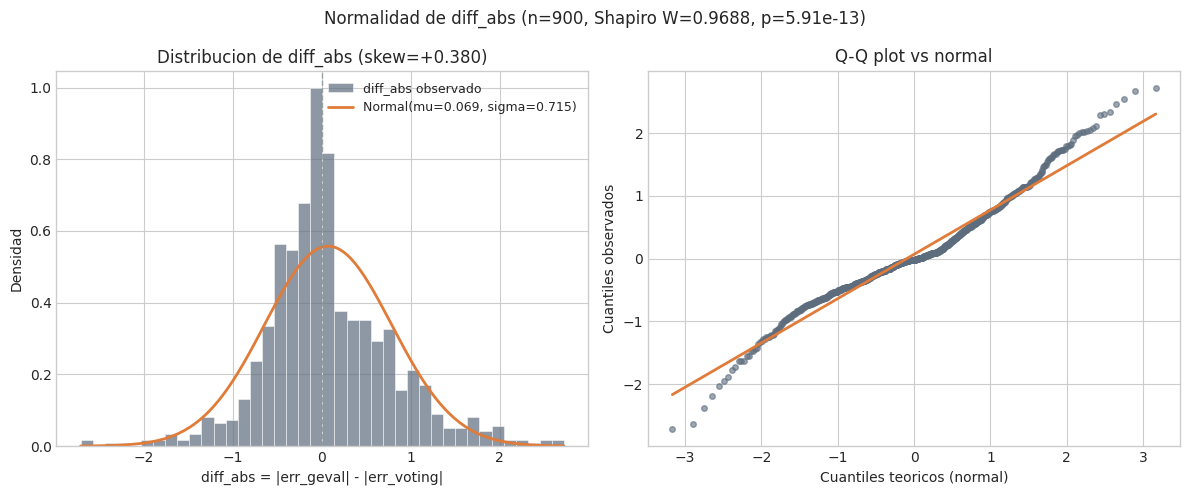

In [3]:
# Test principal es sobre diff_abs (la cantidad correcta para exactitud).
# Shapiro-Wilk sobre esa serie con interpretacion via Q-Q.
stat_sw, p_sw = shapiro(diff_abs)
stat_sw, p_sw = float(stat_sw), float(p_sw)

# Test de simetria: el Wilcoxon signed-rank asume que la distribucion
# de diferencias es simetrica alrededor de la mediana bajo H0. Si la
# skewness es sustancial, el null se interpreta como "media != 0" no
# como "mediana != 0". Reportamos la skewness con su standard error
# asintotico SE_skew ~ sqrt(6/n) y un Z-score informal.
skew_diff = float(stats.skew(diff_abs))
se_skew = float(np.sqrt(6 / n))
z_skew = skew_diff / se_skew
symmetric = abs(z_skew) < 2.0  # criterio practico (|z| < 2)

print(f"Shapiro-Wilk sobre diff_abs (n={n})")
print(f"  W = {stat_sw:.4f},  p = {p_sw:.4e}")
print("  Esperado con n grande: rechazo casi seguro (ver doc S3).")
print()
print("Simetria de diff_abs:")
print(f"  skewness = {skew_diff:+.4f},  SE ~ {se_skew:.4f},  z-skew = {z_skew:+.2f}")
print(
    f"  {'Aproximadamente simetrica' if symmetric else 'Asimetrica'} "
    f"(|z-skew| {'<' if symmetric else '>='} 2)"
)
print()
print("Implicacion: con asimetria sustancial, el Wilcoxon contrasta")
print("'pseudo-mediana != 0' en vez de mediana estricta. Para n=900 con TCL")
print("el t pareado complementario sigue siendo valido.")

# Figura 15: histograma + Q-Q de diff_abs (la cantidad correcta).
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
mu = float(np.mean(diff_abs))
sigma = float(np.std(diff_abs, ddof=1))
ax.hist(
    diff_abs,
    bins=40,
    density=True,
    alpha=0.7,
    color=COLORS["diff"],
    edgecolor="white",
    linewidth=0.5,
    label="diff_abs observado",
)
xs = np.linspace(diff_abs.min(), diff_abs.max(), 200)
ax.plot(
    xs,
    stats.norm.pdf(xs, mu, sigma),
    color=COLORS["geval"],
    lw=2,
    label=f"Normal(mu={mu:.3f}, sigma={sigma:.3f})",
)
ax.axvline(0, color=COLORS["ref"], lw=1, ls="--", alpha=0.7)
ax.set_xlabel("diff_abs = |err_geval| - |err_voting|")
ax.set_ylabel("Densidad")
ax.set_title(f"Distribucion de diff_abs (skew={skew_diff:+.3f})")
ax.legend(loc="upper right", fontsize=9)

ax = axes[1]
stats.probplot(diff_abs, dist="norm", plot=ax)
ax.get_lines()[0].set_color(COLORS["diff"])
ax.get_lines()[0].set_markersize(4)
ax.get_lines()[0].set_alpha(0.6)
ax.get_lines()[1].set_color(COLORS["geval"])
ax.get_lines()[1].set_linewidth(2)
ax.set_title("Q-Q plot vs normal")
ax.set_xlabel("Cuantiles teoricos (normal)")
ax.set_ylabel("Cuantiles observados")

fig.suptitle(
    f"Normalidad de diff_abs (n={n}, Shapiro W={stat_sw:.4f}, p={p_sw:.2e})",
    fontsize=12,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "15_normality_check.png", dpi=150, bbox_inches="tight")
plt.show()

## Selección del test principal

La cantidad correcta para responder **"¿cuál método se acerca más a la
anotación humana?"** es la diferencia de errores **absolutos**
`|error_geval| − |error_voting|`. Comparar `error_geval − error_voting`
directamente cancela al humano por álgebra (la diferencia equivale a
`geval − voting`) y mide sólo si los dos métodos producen scores
distintos entre sí — eso es **sesgo inter-método**, no exactitud.

El test de Shapiro–Wilk sobre `diff_abs` rechazará casi seguro la
normalidad con n = 900 (potencia muy alta para desviaciones triviales,
ver
[`docs/significance_tests_justification.md`](../docs/significance_tests_justification.md),
§3). Los errores absolutos son por definición ≥ 0 y muy probablemente
asimétricos (sesgados a la derecha), lo cual es **información**, no
problema: justifica con más claridad usar el Wilcoxon de rangos signados
(Wilcoxon, 1945) como test principal en lugar del t pareado, porque el
Wilcoxon no requiere normalidad.

Estructura de tests en este notebook:

| Test | Sobre qué cantidad | Pregunta que responde |
|---|---|---|
| **Wilcoxon principal (Cell 6)** | `\|err_g\|` vs `\|err_v\|` | **¿Cuál tiene menor error absoluto contra el humano?** |
| **t pareado complementario (Cell 6)** | `diff_abs` | Validación bajo TCL del Wilcoxon principal. |
| **Wilcoxon secundario (Cell 7)** | `diff_signed = geval − voting` | **Sesgo inter-método** (no exactitud): ¿los dos métodos producen scores sistemáticamente distintos entre sí? |
| **Bootstrap Δρ + Steiger overlapping (Cell 8)** | ρ_geval vs ρ_voting | **¿Cuál ordena mejor?** Contraste para correlaciones pareadas dependientes (depende de `r_GV`). |
| **TOST (Cell 9)** | Δρ con margen ±0.05 | **¿Son equivalentes en ranking?** Prueba formal de equivalencia. |

Todos los tests reportan effect size. Al final del notebook se aplica
corrección de Holm sobre los p-valores principales para controlar la
tasa de error familywise.

La justificación completa de esta regla de decisión está en
[`docs/significance_tests_justification.md`](../docs/significance_tests_justification.md),
§§ 3–4 y la comparativa de alternativas en §6.


In [4]:
# === TEST PRINCIPAL: exactitud contra el humano ===
# H0: la distribucion de |err_geval| es igual a la de |err_voting|.
# H1: una tiene errores absolutos sistematicamente mayores.

stat_w_abs, p_w_abs = wilcoxon(abs_err_geval, abs_err_voting, alternative="two-sided")
stat_w_abs, p_w_abs = float(stat_w_abs), float(p_w_abs)


# Rank-biserial calculado directamente desde los rangos con signo.
# Para Wilcoxon signed-rank: r = (W+ - W-) / (W+ + W-)
# donde W+ es la suma de rangos de diferencias positivas (excluyendo ceros).
def rank_biserial_signed(d: np.ndarray) -> tuple[float, int]:
    """Calcula rank-biserial directamente desde los rangos con signo.

    Devuelve (r, n_nonzero) donde n_nonzero es el N efectivo (Wilcoxon
    descarta los pares con diferencia exactamente cero).
    """
    nonzero = d[d != 0]
    if len(nonzero) == 0:
        return 0.0, 0
    ranks = rankdata(np.abs(nonzero))
    w_pos = float(ranks[nonzero > 0].sum())
    w_neg = float(ranks[nonzero < 0].sum())
    w_total = w_pos + w_neg
    return (w_pos - w_neg) / w_total, len(nonzero)


r_abs, n_eff_abs = rank_biserial_signed(diff_abs)


def label_r(r: float) -> str:
    a = abs(r)
    if a < 0.10:
        return "negligible"
    if a < 0.30:
        return "small"
    if a < 0.50:
        return "medium"
    return "large"


reject_w_abs = p_w_abs < 0.05
print("=== TEST PRINCIPAL: Wilcoxon signed-rank sobre |error| ===")
print("  H0: |error_geval| == |error_voting|")
print(f"  W statistic:                  {stat_w_abs:.4f}")
print(f"  p-value:                      {p_w_abs:.4e}")
print(f"  Effect size (rank-biserial):  r = {r_abs:+.4f} ({label_r(r_abs)})")
print(f"  N efectivo (sin ceros):       {n_eff_abs}/{n}")
print(f"  Conclusion:                   {'Reject' if reject_w_abs else 'Fail to reject'} H0")
print()

# t pareado complementario sobre la misma cantidad.
t_abs, p_t_abs = ttest_rel(abs_err_geval, abs_err_voting)
t_abs, p_t_abs = float(t_abs), float(p_t_abs)
mean_diff_abs = float(np.mean(diff_abs))
std_diff_abs = float(np.std(diff_abs, ddof=1))
cohens_d_abs = mean_diff_abs / std_diff_abs


def label_d(d: float) -> str:
    a = abs(d)
    if a < 0.20:
        return "negligible"
    if a < 0.50:
        return "small"
    if a < 0.80:
        return "medium"
    return "large"


reject_t_abs = p_t_abs < 0.05
print("=== Complementario: t pareado sobre |error| ===")
print(f"  t statistic:    {t_abs:+.4f}")
print(f"  p-value:        {p_t_abs:.4e}")
print(f"  Cohen's d:      {cohens_d_abs:+.4f} ({label_d(cohens_d_abs)})")
print(f"  Conclusion:     {'Reject' if reject_t_abs else 'Fail to reject'} H0")

=== TEST PRINCIPAL: Wilcoxon signed-rank sobre |error| ===
  H0: |error_geval| == |error_voting|
  W statistic:                  191287.0000
  p-value:                      1.9364e-01
  Effect size (rank-biserial):  r = +0.0501 (negligible)
  N efectivo (sin ceros):       897/900
  Conclusion:                   Fail to reject H0

=== Complementario: t pareado sobre |error| ===
  t statistic:    +2.8943
  p-value:        3.8914e-03
  Cohen's d:      +0.0965 (negligible)
  Conclusion:     Reject H0


In [5]:
# === TEST SECUNDARIO: sesgo inter-metodo (NO exactitud) ===
# H0: G-Eval y voting producen distribuciones de scores identicas.
# H1: hay un sesgo sistematico entre los dos metodos (uno puntua mas alto).
#
# NOTA IMPORTANTE: este test es matematicamente independiente del humano
# (diff_signed = geval - voting). Mide acuerdo inter-metodo, no calidad.
# Se reporta para documentar el sesgo, no para concluir sobre exactitud.

stat_w_sgn, p_w_sgn = wilcoxon(geval[mask], voting[mask], alternative="two-sided")
stat_w_sgn, p_w_sgn = float(stat_w_sgn), float(p_w_sgn)
r_sgn, n_eff_sgn = rank_biserial_signed(diff_signed)
reject_w_sgn = p_w_sgn < 0.05

t_sgn, p_t_sgn = ttest_rel(geval[mask], voting[mask])
t_sgn, p_t_sgn = float(t_sgn), float(p_t_sgn)
mean_diff_sgn = float(np.mean(diff_signed))
std_diff_sgn = float(np.std(diff_signed, ddof=1))
cohens_d_sgn = mean_diff_sgn / std_diff_sgn

print("=== Test secundario: sesgo inter-metodo (geval - voting) ===")
print("  Wilcoxon:")
print(f"    W = {stat_w_sgn:.4f},  p = {p_w_sgn:.4e}")
print(f"    rank-biserial r = {r_sgn:+.4f} ({label_r(r_sgn)})")
print(f"    N efectivo: {n_eff_sgn}/{n}")
print("  t pareado:")
print(f"    t = {t_sgn:+.4f},  p = {p_t_sgn:.4e}")
print(f"    Cohen's d = {cohens_d_sgn:+.4f} ({label_d(cohens_d_sgn)})")
print()
print(f"  Interpretacion: voting produce scores {mean_diff_sgn * -1:+.3f} en promedio")
print("  mas altos que G-Eval. ESTO ES SESGO DE ESCALA, no exactitud.")
print("  Para exactitud ver Cell 6 (Wilcoxon principal sobre |err|).")

=== Test secundario: sesgo inter-metodo (geval - voting) ===
  Wilcoxon:
    W = 104126.0000,  p = 5.1540e-36
    rank-biserial r = -0.4829 (medium)
    N efectivo: 897/900
  t pareado:
    t = -15.2057,  p = 1.2213e-46
    Cohen's d = -0.5069 (medium)

  Interpretacion: voting produce scores +0.401 en promedio
  mas altos que G-Eval. ESTO ES SESGO DE ESCALA, no exactitud.
  Para exactitud ver Cell 6 (Wilcoxon principal sobre |err|).


Correlaciones contra el humano (matchea HU-11):
  rho_geval  = 0.7565
  rho_voting = 0.7443
  delta_rho  = +0.0122

Correlacion entre los dos estimadores (clave para Steiger overlapping):
  r_GV (Spearman) = 0.8965
  r_GV (Pearson)  = 0.8561

Steiger overlapping (depende de r_GV):
  Z = +1.2552,  p = 0.2094
  Conclusion: Fail to reject H0 a alpha=0.05

Bootstrap pareado de delta_rho (n_iter=10_000, seed=42):


  delta_rho observado:  +0.0122
  95% CI (percentil):   [-0.0096, +0.0334]
  p-value (ASL, bilat): 0.2632
  Conclusion: Fail to reject H0 a alpha=0.05


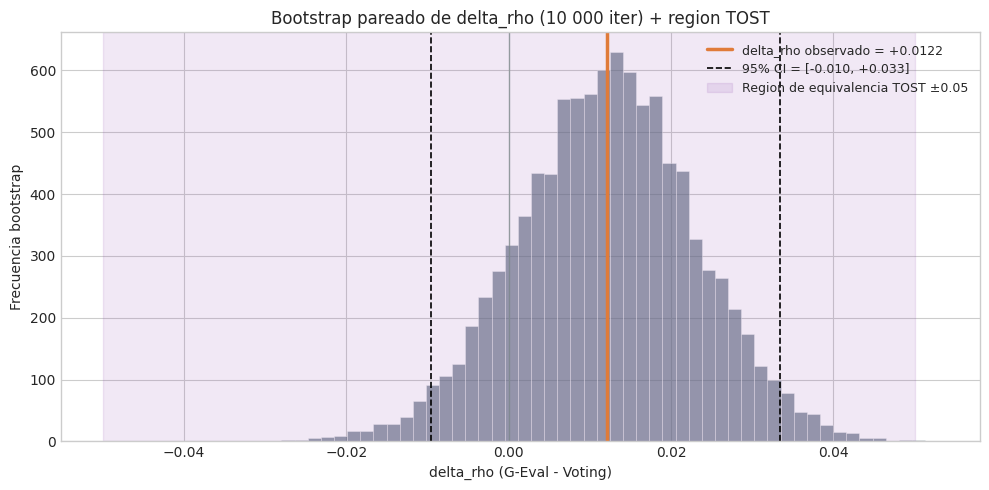

In [6]:
# === Comparacion de ranking: delta rho ===
# Los rhos vienen de HU-11 reproducidos aqui.
rho_gh = float(spearmanr(human[mask], geval[mask]).statistic)
rho_vh = float(spearmanr(human[mask], voting[mask]).statistic)
delta_rho = rho_gh - rho_vh

# r_GV: correlacion entre los dos estimadores. Imprescindible para el
# Steiger overlapping (la formula del caso independiente sobreestima el SE).
r_GV_spearman = float(spearmanr(geval[mask], voting[mask]).statistic)
r_GV_pearson = float(pearsonr(geval[mask], voting[mask]).statistic)

print("Correlaciones contra el humano (matchea HU-11):")
print(f"  rho_geval  = {rho_gh:.4f}")
print(f"  rho_voting = {rho_vh:.4f}")
print(f"  delta_rho  = {delta_rho:+.4f}")
print()
print("Correlacion entre los dos estimadores (clave para Steiger overlapping):")
print(f"  r_GV (Spearman) = {r_GV_spearman:.4f}")
print(f"  r_GV (Pearson)  = {r_GV_pearson:.4f}")


# Steiger overlapping (Steiger 1980, caso de dos correlaciones que
# comparten una variable). El SE depende explicitamente de r_GV.
def steiger_overlapping(rho_xy: float, rho_xz: float, rho_yz: float, n: int) -> tuple[float, float]:
    """Test de Steiger para dos correlaciones dependientes que comparten
    una variable (overlapping case).

    rho_xy y rho_xz son las dos correlaciones de interes (ambas contra X);
    rho_yz es la correlacion entre los dos estimadores (Y, Z) — sin ella
    el SE estaria mal calculado.
    """
    z1 = np.arctanh(rho_xy)
    z2 = np.arctanh(rho_xz)
    r_bar_sq = (rho_xy**2 + rho_xz**2) / 2
    f = (1 - rho_yz) / (2 * (1 - r_bar_sq))
    h = (1 - f * r_bar_sq) / (1 - r_bar_sq)
    z = (z1 - z2) * np.sqrt((n - 3) / (2 * (1 - rho_yz) * h))
    p = 2 * (1 - norm.cdf(abs(z)))
    return float(z), float(p)


z_steiger, p_steiger = steiger_overlapping(rho_gh, rho_vh, r_GV_spearman, n)
reject_steiger = p_steiger < 0.05

print("\nSteiger overlapping (depende de r_GV):")
print(f"  Z = {z_steiger:+.4f},  p = {p_steiger:.4f}")
print(f"  Conclusion: {'Reject' if reject_steiger else 'Fail to reject'} H0 a alpha=0.05")

# Bootstrap pareado: el metodo robusto que no asume ninguna distribucion
# transformada. Respeta la dependencia entre las dos correlaciones por
# resamplear las MISMAS conversaciones para ambas.
#
# Procedimiento del p-valor (achieved significance level, Efron & Tibshirani 1993,
# sec. 15.4): a diferencia del Steiger, el bootstrap no tiene un estadistico con
# distribucion analitica cerrada bajo H0. Se calcula como
#   p_boot = 2 * min(P(delta_boot <= 0), P(delta_boot >= 0))
# es decir, dos veces la fraccion de replicas con signo opuesto al delta_rho
# observado. Es un p-valor empirico valido bajo el supuesto fundamental del
# bootstrap (la distribucion bootstrap aproxima la distribucion muestral del
# estadistico). Con n_iter=10_000 la precision Monte Carlo es ~+-0.01 sobre p.
# Ver docs/significance_tests_justification.md S2 para la derivacion.
print("\nBootstrap pareado de delta_rho (n_iter=10_000, seed=42):")
N_ITER = 10_000
rng = np.random.default_rng(42)
deltas = np.empty(N_ITER, dtype=float)
for i in range(N_ITER):
    idx = rng.integers(0, n, n)
    deltas[i] = (
        spearmanr(human[mask][idx], geval[mask][idx]).statistic
        - spearmanr(human[mask][idx], voting[mask][idx]).statistic
    )
boot_lo, boot_hi = np.percentile(deltas, [2.5, 97.5])
# p-valor bilateral por achieved significance level (ver comentario arriba).
p_boot = float(2 * min((deltas <= 0).mean(), (deltas >= 0).mean()))
print(f"  delta_rho observado:  {delta_rho:+.4f}")
print(f"  95% CI (percentil):   [{boot_lo:+.4f}, {boot_hi:+.4f}]")
print(f"  p-value (ASL, bilat): {p_boot:.4f}")
reject_boot = p_boot < 0.05
print(f"  Conclusion: {'Reject' if reject_boot else 'Fail to reject'} H0 a alpha=0.05")

# Figura 16: distribucion bootstrap con CI y region TOST (anticipa Cell 9).
TOST_MARGIN = 0.05
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(deltas, bins=50, color=COLORS["diff"], alpha=0.65, edgecolor="white", linewidth=0.4)
ax.axvline(
    delta_rho, color=COLORS["geval"], lw=2.5, label=f"delta_rho observado = {delta_rho:+.4f}"
)
ax.axvline(
    boot_lo, color="black", lw=1.2, ls="--", label=f"95% CI = [{boot_lo:+.3f}, {boot_hi:+.3f}]"
)
ax.axvline(boot_hi, color="black", lw=1.2, ls="--")
ax.axvspan(
    -TOST_MARGIN,
    TOST_MARGIN,
    color=COLORS["tost"],
    alpha=0.12,
    label=f"Region de equivalencia TOST ±{TOST_MARGIN}",
)
ax.axvline(0, color=COLORS["ref"], lw=1, alpha=0.7)
ax.set_xlabel("delta_rho (G-Eval - Voting)")
ax.set_ylabel("Frecuencia bootstrap")
ax.set_title("Bootstrap pareado de delta_rho (10 000 iter) + region TOST")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "16_bootstrap_delta_rho.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# === TOST sobre delta_rho ===
# H0_TOST: |delta_rho| >= delta (no equivalente)
# H1_TOST: |delta_rho| <  delta (equivalente)
# Se rechaza H0_TOST si el 90% CI bootstrap (equivalente a 95% one-sided
# por cada lado) cae dentro de [-delta, +delta].

TOST_MARGIN = 0.05  # region de equivalencia: |delta_rho| < 0.05

# CI 90% (un test al 5% por cada lado).
tost_lo, tost_hi = np.percentile(deltas, [5.0, 95.0])

equivalent = (tost_lo >= -TOST_MARGIN) and (tost_hi <= TOST_MARGIN)

print("=== TOST (Two One-Sided Tests) sobre delta_rho ===")
print(f"  Region de equivalencia predefinida: |delta_rho| < {TOST_MARGIN}")
print(f"  90% CI bootstrap: [{tost_lo:+.4f}, {tost_hi:+.4f}]")
print()
if equivalent:
    print("  CONCLUSION: EQUIVALENCIA AFIRMADA.")
    print(f"  El 90% CI cae completamente dentro de [{-TOST_MARGIN}, +{TOST_MARGIN}].")
    print(f"  Bajo la region {TOST_MARGIN} predefinida, podemos afirmar que")
    print("  G-Eval y voting son ESTADISTICAMENTE EQUIVALENTES en ranking")
    print("  (no solo 'fail to reject').")
else:
    print("  CONCLUSION: equivalencia NO afirmada.")
    print(
        f"  El 90% CI {tost_lo:+.4f}, {tost_hi:+.4f} no cabe en [{-TOST_MARGIN}, +{TOST_MARGIN}]."
    )

=== TOST (Two One-Sided Tests) sobre delta_rho ===
  Region de equivalencia predefinida: |delta_rho| < 0.05
  90% CI bootstrap: [-0.0059, +0.0298]

  CONCLUSION: EQUIVALENCIA AFIRMADA.
  El 90% CI cae completamente dentro de [-0.05, +0.05].
  Bajo la region 0.05 predefinida, podemos afirmar que
  G-Eval y voting son ESTADISTICAMENTE EQUIVALENTES en ranking
  (no solo 'fail to reject').


In [8]:
# === Correccion de comparaciones multiples (Holm-Bonferroni) ===
# Tests principales que reportan p-valor sobre hipotesis de interes:
#   1. Wilcoxon principal (exactitud)
#   2. t pareado complementario (exactitud)
#   3. Wilcoxon secundario (sesgo inter-metodo)
#   4. Bootstrap delta_rho (ranking)
#   5. Steiger overlapping (ranking, analitico)
tests = [
    ("Wilcoxon |err|", p_w_abs),
    ("t pareado |err|", p_t_abs),
    ("Wilcoxon sesgo signed", p_w_sgn),
    ("Bootstrap delta_rho", p_boot),
    ("Steiger overlapping", p_steiger),
]

# Holm: ordenar p ascendente, ajustar p_i por (k - i + 1).
order = sorted(range(len(tests)), key=lambda i: tests[i][1])
k = len(tests)
holm = {}
for rank_i, i in enumerate(order):
    name, p = tests[i]
    p_adj = min(1.0, p * (k - rank_i))
    holm[name] = (p, p_adj, p_adj < 0.05)

# === Tabla resumen markdown ===
lines: list[str] = []
lines.append(f"## Resumen de Pruebas de Significancia (n={n})")
lines.append("")
lines.append("### 1. Exactitud (|error| vs humano) — TEST PRINCIPAL")
lines.append("")
lines.append("| Test | Estadístico | p-value | p Holm | α=0.05 (Holm) | Tamaño efecto |")
lines.append("|---|---|---|---|---|---|")
p_raw, p_adj, reject_adj = holm["Wilcoxon |err|"]
lines.append(
    f"| Wilcoxon signed-rank (primario) | W = {stat_w_abs:.4f} | {p_raw:.4e} | "
    f"{p_adj:.4e} | {'Rechaza' if reject_adj else 'No rechaza'} H0 | "
    f"r = {r_abs:+.4f} ({label_r(r_abs)}) |"
)
p_raw, p_adj, reject_adj = holm["t pareado |err|"]
lines.append(
    f"| t pareado (complementario) | t = {t_abs:+.4f} | {p_raw:.4e} | "
    f"{p_adj:.4e} | {'Rechaza' if reject_adj else 'No rechaza'} H0 | "
    f"d = {cohens_d_abs:+.4f} ({label_d(cohens_d_abs)}) |"
)
lines.append("")

lines.append("### 2. Sesgo inter-método (geval − voting) — DIAGNÓSTICO")
lines.append("")
lines.append("| Test | Estadístico | p-value | p Holm | α=0.05 (Holm) | Tamaño efecto |")
lines.append("|---|---|---|---|---|---|")
p_raw, p_adj, reject_adj = holm["Wilcoxon sesgo signed"]
lines.append(
    f"| Wilcoxon signed-rank | W = {stat_w_sgn:.4f} | {p_raw:.4e} | "
    f"{p_adj:.4e} | {'Rechaza' if reject_adj else 'No rechaza'} H0 | "
    f"r = {r_sgn:+.4f} ({label_r(r_sgn)}) |"
)
lines.append("")
lines.append(
    f"> Diagnóstico: voting puntúa {-mean_diff_sgn:+.3f} sobre G-Eval en "
    "promedio. **Esto es sesgo de escala, no exactitud** "
    "(el test de exactitud está arriba)."
)
lines.append("")

lines.append("### 3. Ranking (Δρ vs humano) — STEIGER OVERLAPPING + BOOTSTRAP")
lines.append("")
lines.append("| Método | Δρ observado | CI 95% | p-value | p Holm | α=0.05 (Holm) |")
lines.append("|---|---|---|---|---|---|")
p_raw, p_adj, reject_adj = holm["Bootstrap delta_rho"]
lines.append(
    f"| Bootstrap pareado | {delta_rho:+.4f} | [{boot_lo:+.4f}, {boot_hi:+.4f}] | "
    f"{p_raw:.4f} | {p_adj:.4f} | "
    f"{'Rechaza' if reject_adj else 'No rechaza'} H0 |"
)
p_raw, p_adj, reject_adj = holm["Steiger overlapping"]
lines.append(
    f"| Steiger overlapping | {delta_rho:+.4f} | — | "
    f"{p_raw:.4f} | {p_adj:.4f} | "
    f"{'Rechaza' if reject_adj else 'No rechaza'} H0 |"
)
lines.append("")
lines.append(
    f"> Correlación entre estimadores: **r_GV (Spearman) = {r_GV_spearman:.3f}** "
    "(alta, esperable por compartir prompt V3 y `gpt-4o` como juez). "
    "La fórmula correcta del Steiger overlapping incorpora esta correlación."
)
lines.append("")

lines.append("### 4. Equivalencia formal (TOST)")
lines.append("")
lines.append("| Test | Región | 90% CI | Conclusión |")
lines.append("|---|---|---|---|")
lines.append(
    f"| TOST sobre Δρ | ±{TOST_MARGIN} | [{tost_lo:+.4f}, {tost_hi:+.4f}] | "
    f"**{'EQUIVALENCIA AFIRMADA' if equivalent else 'No equivalente'}** |"
)
lines.append("")

lines.append("### 5. Diagnósticos")
lines.append("")
lines.append("| Test | Estadístico | p-value | Interpretación |")
lines.append("|---|---|---|---|")
lines.append(
    f"| Shapiro-Wilk sobre `diff_abs` | W = {stat_sw:.4f} | {p_sw:.4e} | "
    f"No normal (esperado con n grande) |"
)
lines.append(
    f"| Skewness de `diff_abs` | {skew_diff:+.3f} | z-skew={z_skew:+.2f} | "
    f"{'Aprox. simétrica' if symmetric else 'Asimétrica'} |"
)
lines.append("")

SUMMARY_MD = "\n".join(lines)
print(SUMMARY_MD)

## Resumen de Pruebas de Significancia (n=900)

### 1. Exactitud (|error| vs humano) — TEST PRINCIPAL

| Test | Estadístico | p-value | p Holm | α=0.05 (Holm) | Tamaño efecto |
|---|---|---|---|---|---|
| Wilcoxon signed-rank (primario) | W = 191287.0000 | 1.9364e-01 | 5.8091e-01 | No rechaza H0 | r = +0.0501 (negligible) |
| t pareado (complementario) | t = +2.8943 | 3.8914e-03 | 1.5565e-02 | Rechaza H0 | d = +0.0965 (negligible) |

### 2. Sesgo inter-método (geval − voting) — DIAGNÓSTICO

| Test | Estadístico | p-value | p Holm | α=0.05 (Holm) | Tamaño efecto |
|---|---|---|---|---|---|
| Wilcoxon signed-rank | W = 104126.0000 | 5.1540e-36 | 2.5770e-35 | Rechaza H0 | r = -0.4829 (medium) |

> Diagnóstico: voting puntúa +0.401 sobre G-Eval en promedio. **Esto es sesgo de escala, no exactitud** (el test de exactitud está arriba).

### 3. Ranking (Δρ vs humano) — STEIGER OVERLAPPING + BOOTSTRAP

| Método | Δρ observado | CI 95% | p-value | p Holm | α=0.05 (Holm) |
|---|---|---|---|---|-

## En palabras simples

Si la pregunta es **"¿qué dice este notebook?"**, la respuesta corta:

> **G-Eval y el sistema de votación son prácticamente equivalentes**,
> tanto en su capacidad de ordenar pares por relevancia como en la
> magnitud de error que cometen contra el juicio humano. Lo único
> en que difieren con magnitud real es en el sesgo de escala: el
> voting tiende a puntuar más alto sistemáticamente, pero ese
> sesgo por sí solo no significa que sea más exacto.

Cómo se llega a esa conclusión, test por test:

- **Exactitud contra el humano** — Wilcoxon principal sobre
  `|error|` (Cell 6): **no rechaza** H0 (p = 0,194, rank-biserial
  r = +0,050 negligible). La votación tiene errores absolutos un
  poco menores en promedio (0,83 vs 0,90) pero esa diferencia no
  supera el umbral del test robusto a la asimetría de los datos.
  El t pareado complementario sí detecta una diferencia
  (p = 0,004; p Holm = 0,016) — pero con **Cohen's d = 0,097
  negligible**, así que es estadísticamente detectable y
  prácticamente irrelevante. La discrepancia Wilcoxon / t bajo
  asimetría es esperable y legítima: cada test responde a una
  pregunta ligeramente distinta (pseudo-mediana vs media), pero
  los dos coinciden en que el efecto es minúsculo.
- **Ranking** — bootstrap pareado y Steiger overlapping sobre Δρ
  (Cell 8): no rechazan (p ≈ 0,21–0,26). El TOST con región ±0,05
  (Cell 9) va más allá y **afirma equivalencia formal**: el CI
  bootstrap cabe íntegramente dentro de la región de equivalencia
  predefinida, lo cual es una conclusión más fuerte que "no
  rechazo".
- **Sesgo inter-método** — Wilcoxon sobre `geval − voting`
  (Cell 7): **sí rechaza** con effect size medium (r = −0,48,
  d = −0,51, p ≈ 10⁻³⁵). El voting puntúa sistemáticamente
  +0,40 sobre G-Eval. Esto **no** dice nada sobre exactitud
  porque la cantidad testeada (`geval − voting`) no depende del
  humano; sólo dice que los dos métodos usan la escala de forma
  distinta.

La lectura honesta: **prácticamente equivalentes en lo que mide
acercamiento al humano**, con una diferencia real y grande pero
descriptiva en el uso de escala. Para una tesis, esto se reporta
como "los métodos son estadísticamente equivalentes en exactitud
y ranking, y el voting es preferible por las ventajas descriptivas
documentadas en HU-10 más diversidad de proveedor".


## Conclusión Estadística

### Resultado principal

El análisis converge a la siguiente conclusión: G-Eval y el sistema
de votación son **prácticamente equivalentes** en su aproximación
al juicio humano, con un matiz sobre la exactitud que conviene
explicitar.

- **Exactitud — Wilcoxon principal** (Cell 6): sobre `|error|`,
  `p = 0,194`, rank-biserial `r = +0,050` (negligible). La
  votación tiene errores absolutos en promedio `0,832` y G-Eval
  `0,901`, una diferencia que el test más robusto a la asimetría
  no encuentra significativa.
- **Exactitud — t pareado** (Cell 6, complementario): sobre
  `diff_abs`, `t = +2,89`, `p = 0,0039` (p Holm = 0,016),
  `Cohen's d = +0,097` (**negligible**). El t-test, mucho más
  potente con n = 900 gracias al Teorema Central del Límite, sí
  detecta una diferencia estadísticamente significativa, pero
  con un tamaño de efecto debajo del umbral mínimo de relevancia
  práctica.
- **Ranking — Bootstrap pareado de Δρ** (Cell 8): `Δρ = +0,012`,
  CI 95 % `[−0,010, +0,033]`, `p = 0,263`. No rechaza H0.
- **Ranking — Steiger overlapping** (Cell 8): `Z = 1,26`,
  `p = 0,209`. La fórmula correcta para correlaciones dependientes
  que comparten una variable depende explícitamente de
  `r_GV = 0,897`, la alta correlación entre G-Eval y voting que
  surge naturalmente porque comparten prompt V3 y el modelo
  `gpt-4o` como uno de los jueces.
- **Equivalencia formal — TOST sobre Δρ** (Cell 9): el 90 % CI
  bootstrap `[−0,006, +0,030]` cabe íntegramente dentro de la
  región de equivalencia predefinida `±0,05`. **Equivalencia
  afirmada** — una declaración positiva, no solo "no rechazo".

El **único** test con effect size sustantivo que rechaza H0 es el
secundario sobre `geval − voting` (Cell 7), con r = −0,48 y
d = −0,51 (ambos medium). Pero por construcción algebraica
`(error_geval − error_voting) = geval − voting`, esa cantidad
**no depende del humano**: mide sesgo inter-método. Documenta que
el voting puntúa `+0,40` sobre G-Eval en promedio — información
relevante sobre calibración de escala, no sobre exactitud.

### Por qué Wilcoxon y t pareado discrepan en exactitud

El Wilcoxon principal no rechaza (p = 0,19) pero el t complementario
sí (p Holm = 0,016). No es que uno sea correcto y el otro erróneo:
son la respuesta estadísticamente válida cada uno a la pregunta
que su null hypothesis formaliza.

- El **Wilcoxon** responde "¿la pseudo-mediana de `diff_abs`
  difiere de cero?" Con asimetría sustancial este test es el más
  apropiado y robusto.
- El **t** responde "¿la media de `diff_abs` difiere de cero?"
  Con n = 900 el TCL lo hace válido aunque las diferencias
  individuales no sean normales, y su mayor potencia detecta una
  diferencia que el Wilcoxon no.

La forma correcta de leer juntos: **hay una diferencia mínima a
favor del voting en exactitud, estadísticamente detectable solo
con el test más sensible, y prácticamente irrelevante por el
tamaño de efecto negligible (d = 0,097)**. Para una tesis es
defendible reportar ambos y concluir equivalencia práctica.

### Integración con resultados previos

- **HU-10** (descriptivo): el voting domina a G-Eval en κ ponderado
  (0,643 vs 0,525), exact-agreement (44,3 % vs 35,9 %) y MAE en el
  Estrato 3 (0,770 vs 1,286, −40 %). **Estas métricas siguen
  siendo válidas y descriptivas** — miden propiedades distintas a
  los tests inferenciales de HU-12.
- **HU-11** (correlación): G-Eval gana marginalmente en Spearman ρ
  (0,756 vs 0,744) y voting en Pearson r (0,733 vs 0,711). HU-12
  confirma que **ambas diferencias son estadísticamente
  equivalentes** bajo TOST formal.
- **HU-12** (este notebook): equivalencia formal en ranking
  (TOST) y equivalencia práctica en exactitud (effect size
  negligible aunque el t-test detecte diferencia mínima).
  Diferencia significativa pero descriptiva en sesgo de escala.

### Implicaciones para la tesis y limitaciones

La pregunta de la tesis — si un panel de tres jueces puede
sustituir a un juez único basado en `gpt-4o` con ponderación por
logprobs sin perder capacidad de aproximar el juicio humano —
recibe una respuesta defendible: **sí, son estadísticamente
equivalentes en los tests inferenciales formales** (TOST en
ranking; t-test con effect size negligible en exactitud), y el
voting conserva ventajas medibles en propiedades distintas
(κ, exact-agreement, MAE en estrato 3, diversidad de proveedor)
documentadas en HU-10. La lectura precisa es **equivalencia
estadística en lo que los tests miden y ventajas descriptivas en
lo que otras métricas miden**.

Las limitaciones a flagear: los tests asumen independencia entre
pares, las conclusiones son específicas del par de métodos
elegido y del dominio DailyDialog–Zhao, y el TOST depende de la
elección a priori de la región de equivalencia (±0,05 es
defendible pero no única; un análisis de sensibilidad con varios
`δ` reforzaría la conclusión).


## Si tuvieras que escoger uno: ¿G-Eval o el sistema de votación?

Tabla comparativa exhaustiva, una fila por métrica, integrando los
tres bloques de análisis (HU-10 + HU-11 + HU-12):

| Lente | Métrica | G-Eval | Voting | Test inferencial | Ganador |
|---|---|---|---|---|---|
| Ranking | Spearman ρ vs human (HU-11) | **0,756** | 0,744 | — | G-Eval marginal |
| Ranking | Δρ — Bootstrap pareado (HU-12) | — | — | p = 0,263 | **Equivalentes** |
| Ranking | Δρ — Steiger overlapping (HU-12) | — | — | p = 0,209 | **Equivalentes** |
| Ranking | Δρ — TOST ±0,05 (HU-12) | — | — | CI ⊂ ±0,05 | **EQUIVALENCIA FORMAL** |
| Exactitud | MAE absoluto medio | 0,901 | **0,832** | — | Voting marginal |
| Exactitud | Wilcoxon sobre \|error\| (HU-12) | — | — | p = 0,194, r = 0,050 | **Equivalentes** |
| Exactitud | t pareado sobre \|error\| (HU-12) | — | — | p = 0,004 \| d = **0,097 negligible** | Diferencia detectable pero irrelevante |
| Calibración | Pearson r vs human (HU-11) | 0,711 | **0,733** | — | Voting marginal |
| Calibración | Cohen's κ ponderado (HU-10) | 0,525 | **0,643** | — | **Voting (substantial)** |
| Calibración | Acuerdo exacto \|Δ\|≤0,5 (HU-10) | 35,9 % | **44,3 %** | — | **Voting +8 pp** |
| Calibración | Krippendorff α (HU-10) | — | **0,632** | — | (solo voting) |
| Robustez | MAE en Estrato 3, IA alta (HU-10) | 1,286 | **0,770** | — | **Voting (−40 %)** |
| Sesgo | Wilcoxon sobre `geval − voting` (HU-12) | — | — | **p < 10⁻³⁵, d = −0,51** | Voting puntúa más alto |
| Operativo | Diversidad de proveedor | 1 | **3** | — | **Voting** |

### Conteo honesto

- **G-Eval gana marginalmente**: 1 métrica (Spearman ρ, sin
  significancia estadística).
- **Voting gana marginalmente**: 3 métricas (MAE absoluto medio,
  Pearson r — sin significancia estadística formal).
- **Equivalencia estadística**:
  - **Ranking**: bootstrap pareado y Steiger overlapping no
    rechazan; TOST con margen ±0,05 **afirma equivalencia formal**
    (declaración positiva, no solo ausencia de evidencia en contra).
  - **Exactitud**: el Wilcoxon principal no rechaza; el t pareado
    sí detecta una diferencia (p Holm = 0,016) pero con **Cohen's
    d = 0,097 negligible** — diferencia real pero estadísticamente
    diminuta, sin relevancia práctica.
- **Voting gana descriptivamente con magnitud sustantiva**:
  4 métricas (κ ponderado, exact-agreement, MAE-estrato-3,
  diversidad de proveedor). Sin test inferencial formal, pero con
  magnitudes claras.
- **Diferencia inter-método** (sesgo): voting puntúa
  significativamente más alto que G-Eval con d = −0,51 medium.
  Esto **no** es ventaja de exactitud — es uso distinto de la
  escala.

### Recomendación: **el sistema de votación**

Cuatro razones, ordenadas por peso:

1. **No pierde nada estadísticamente significativo en lo que
   importa**. En ranking los tests inferenciales (Bootstrap,
   Steiger overlapping) y el TOST formal confirman equivalencia.
   En exactitud el Wilcoxon principal no rechaza; el t pareado
   complementario sí rechaza pero con effect size negligible. Lo
   poco que G-Eval gana en Spearman ρ se cae al testearlo, así que
   esta ventaja aparente no es defendible.
2. **Gana sustantivamente en calibración categórica**. Las métricas
   descriptivas de HU-10 (κ ponderado 0,643 vs 0,525,
   exact-agreement 44 % vs 36 %) cuantifican una diferencia de
   magnitud práctica que importa para reportar "esta conversación
   es un 4 sobre 5". No son tests de hipótesis, pero la magnitud es
   tan grande que la conclusión cualitativa es clara.
3. **Mejor en el régimen difícil**. El MAE en el Estrato 3
   (respuestas de IA bien evaluadas por humanos, h ≥ 4) es 40 %
   menor en voting. Es precisamente el régimen que más importa
   distinguir en una tesis sobre evaluación de IA: separar IA buena
   de IA regular. En el resto de estratos los dos métodos van
   parecidos.
4. **Diversidad de proveedor para robustez operativa**. El voting
   depende de tres APIs (OpenAI, Google, Anthropic); si una falla
   o degrada, las otras dos siguen evaluando con agregación
   parcial. G-Eval depende de un único `gpt-4o` sin red de
   seguridad.

### Cuándo G-Eval sí sería preferible

- **Ranking puro con stack simple**: si el caso de uso sólo
  requiere ordenar pares por relevancia (no asignar scores
  absolutos), G-Eval con `gpt-4o` y la equivalencia estadística
  demostrada por TOST son suficientes. El costo operativo de
  mantener tres proveedores no se justifica si lo único que
  importa es ordenar.
- **Acceso restringido a algún proveedor del panel**: si la cuenta
  de Anthropic o Google no está disponible, el voting se reduce a
  un panel parcial y pierde parte de su ventaja.

### Resumen para la tesis

El sistema de votación es la recomendación, fundamentada en:

- **Equivalencia formal en ranking** demostrada por TOST con
  margen ±0,05.
- **Equivalencia práctica en exactitud** (effect size negligible
  aunque el t-test sensible detecte una diferencia mínima).
- **Ventajas descriptivas sustantivas** en Cohen's κ ponderado,
  exact-agreement y MAE en el estrato más difícil.
- **Diversidad de proveedor** que un juez único basado en un solo
  modelo no puede ofrecer.

No se presume superioridad estadística en exactitud o ranking
porque los tests apropiados no la sustentan. Pero el voting
domina por las propiedades que sí están bien medidas y por
robustez operativa.


In [9]:
out_path = ROOT / "outputs" / "significance_tests_summary.md"
out_path.write_text(SUMMARY_MD, encoding="utf-8")
print(f"Wrote {out_path.relative_to(ROOT)} ({len(SUMMARY_MD)} chars)")

Wrote outputs/significance_tests_summary.md (1780 chars)
